In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
stocks = [
    "TCS",
    "Infosys",
    "Reliance",
    "HDFC",
    "ITC"
]

data = {}

for stock in stocks:

    df = pd.read_csv(
        f"Data_with_returns/{stock}_returns.csv"
    )

    df["Date"] = pd.to_datetime(df["Date"])

    data[stock] = df

In [6]:
data['TCS']

,Date,Close_price,High_price,Low_price,Open_price,Volume,Return,Return_pct
0,2019-01-02,1577.818115,1586.965163,1558.703449,1562.805300,2100463,0.010774,1.077362
1,2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668,-0.012141,-1.214067
2,2019-01-04,1539.711914,1559.687910,1510.301660,1558.703506,4280862,-0.012158,-1.215814
3,2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423,0.011215,1.121537
4,2019-01-08,1553.411499,1563.953232,1545.002707,1563.132863,1691756,-0.002292,-0.229216
...,...,...,...,...,...,...,...,...
1474,2024-12-23,3893.971191,3948.940020,3853.330069,3933.067290,2195338,-0.002878,-0.287752
1475,2024-12-24,3913.824463,3949.877159,3893.971886,3893.971886,1181886,0.005098,0.509846
1476,2024-12-26,3904.085693,3932.974763,3879.785057,3913.824512,1208464,-0.002488,-0.248830
1477,2024-12-27,3900.105469,3915.182141,3883.624146,3898.372975,858100,-0.001020,-0.101950


# Summary Statistics Table

In [39]:


summary = []  

for stock,df in data.items():

    summary.append({

        "Stock": stock,

        "Mean Return":
        df["Return"].mean(),

        "Volatility":
        df["Return"].std(),

        "Min Return":
        df["Return"].min(), # worst day

        "Max Return":
        df["Return"].max(), # best day

        "Skewness":
        df["Return"].skew(),

        "Kurtosis":
        df["Return"].kurtosis()

    })

summary_df = pd.DataFrame(summary)

summary_df

,Stock,Mean Return,Volatility,Min Return,Max Return,Skewness,Kurtosis
0,TCS,0.000735,0.015252,-0.094104,0.098451,0.027261,4.568335
1,Infosys,0.000972,0.017546,-0.161881,0.120334,-0.447590,10.489569
2,Reliance,0.000767,0.018463,-0.131539,0.147180,0.442707,9.943862
3,HDFC,0.000510,0.016488,-0.126069,0.115996,-0.085293,9.070140
4,ITC,0.000645,0.015808,-0.120798,0.084337,-0.385659,9.417673


* Most stocks will show large kurtosis which says normal distribution may fail.

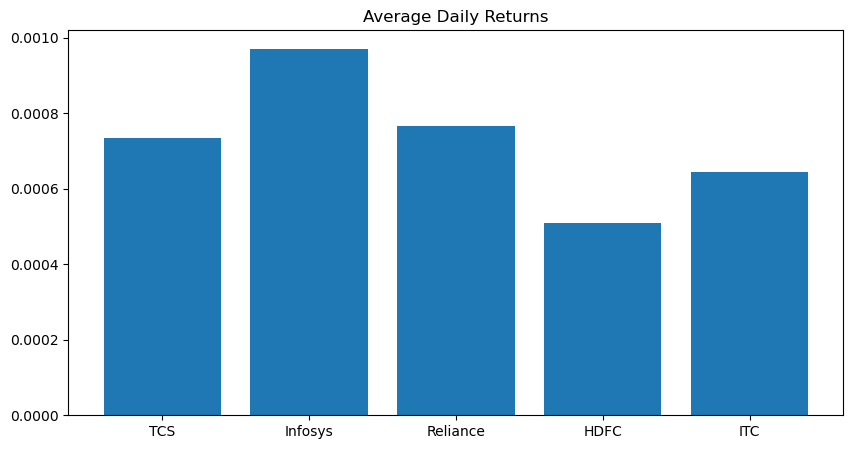

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    summary_df["Stock"],
    summary_df["Mean Return"]
)

plt.title(
    "Average Daily Returns"
)

plt.show()

* So, Infosys stock gives ths best results.

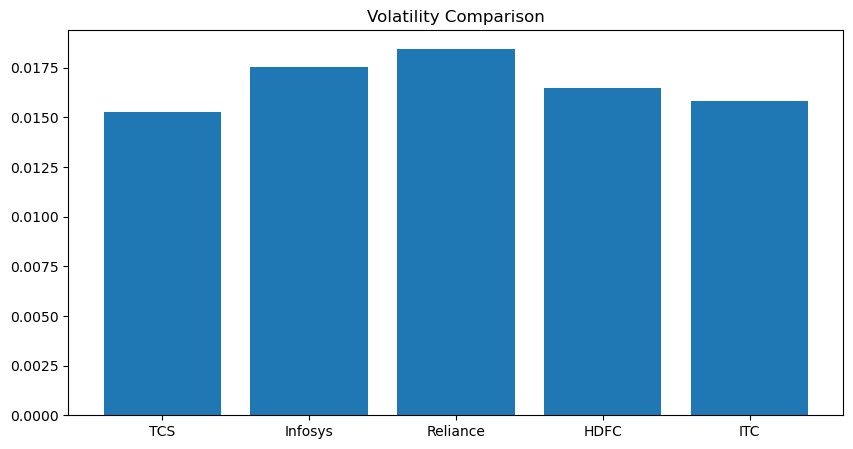

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    summary_df["Stock"],
    summary_df["Volatility"]
)

plt.title(
    "Volatility Comparison"
)

plt.show()

* So, Reliance stock is the most riskiest one.

# Check for Normal Curve

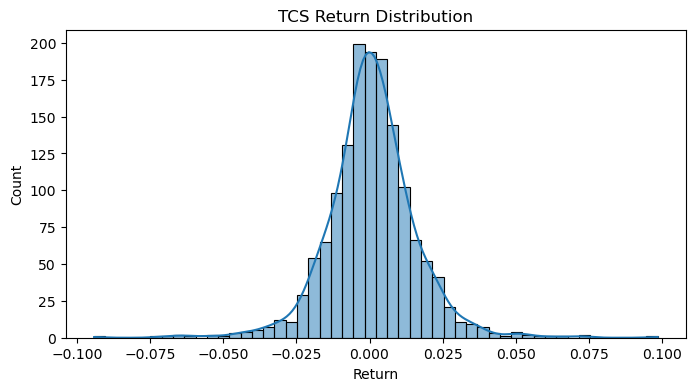

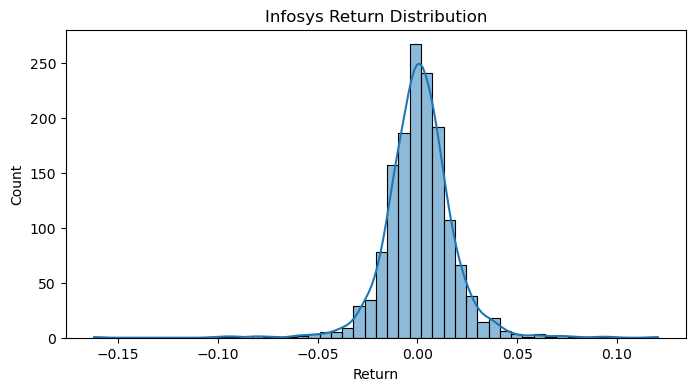

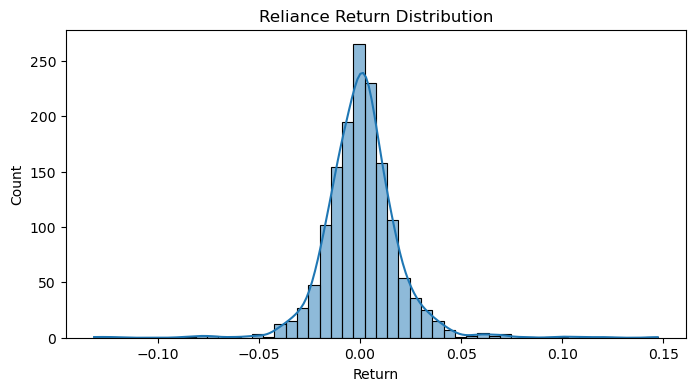

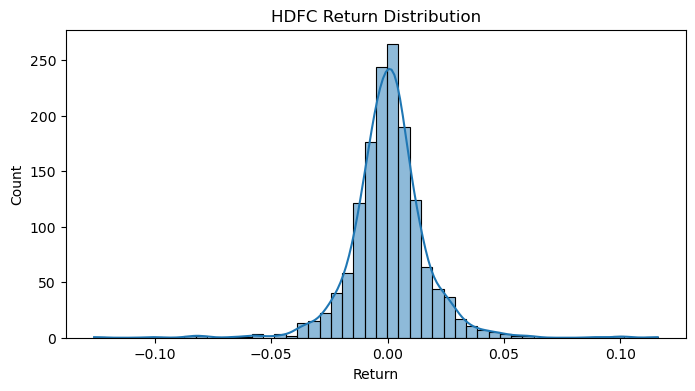

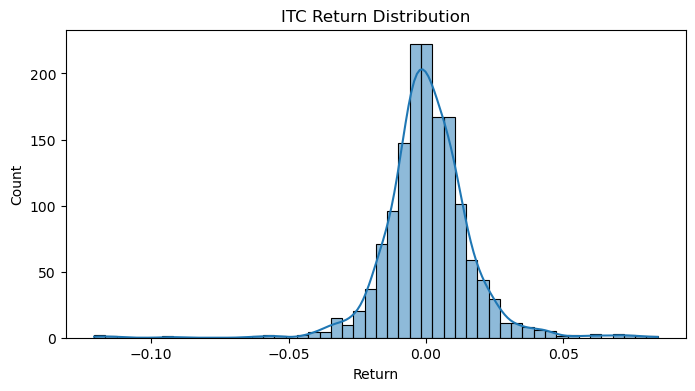

In [40]:
for stock,df in data.items():

    plt.figure(figsize=(8,4))

    sns.histplot(
        df["Return"],
        bins=50,
        kde=True
    )

    plt.title(
        f"{stock} Return Distribution"
    )

    plt.show() #if returns are perfectly normal then it will give us bell curve.

Daily return distributions exhibit approximately bell-shaped behavior centered near zero, supporting the use of Gaussian likelihoods as a baseline model. However, the presence of heavy tails and extreme observations suggests departures from normality, motivating the consideration of Student-t models in later stages of Bayesian model comparison.

In [21]:
data['Infosys'].isnull().sum()

Date           0
Close_price    0
High_price     0
Low_price      0
Open_price     0
Volume         0
Return         0
Return_pct     0
dtype: int64

In [22]:
print(type(data))

<class 'dict'>


In [31]:
print(data.keys())

dict_keys(['TCS', 'Infosys', 'Reliance', 'HDFC', 'ITC'])


In [25]:
for s in stocks:
    print(s)

TCS
Infosys
Reliance
HDFC
ITC


# Check for Outliers

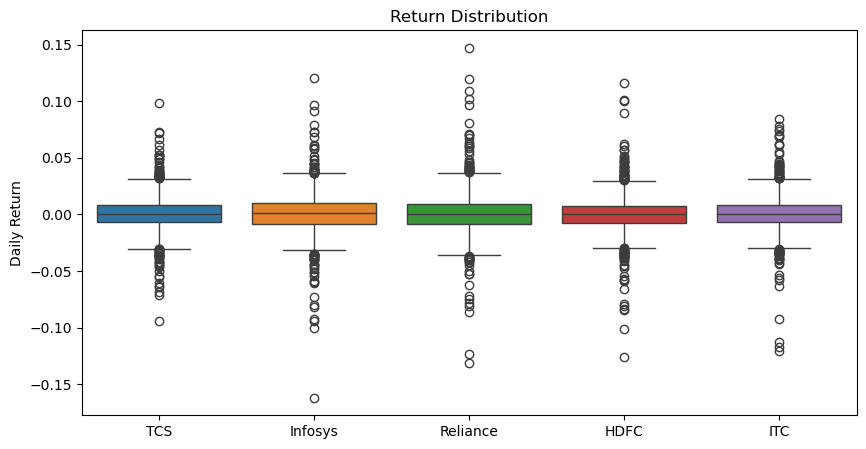

In [35]:
returns_df = pd.DataFrame()

for stock in stocks:
    returns_df[stock] = data[stock]["Return"]

plt.figure(figsize=(10,5))
sns.boxplot(data=returns_df)

plt.title("Return Distribution")
plt.ylabel("Daily Return")
plt.show()
 # For checking the outliers(extreme gains or extreme losses)

* From this reliance stocks are having most outlier values.

# Correlation Matrix

In [36]:
returns = pd.DataFrame()

for stock,df in data.items():

    returns[stock] = df["Return"].values

In [38]:
corr_matrix = returns.corr()

corr_matrix

,TCS,Infosys,Reliance,HDFC,ITC
TCS,1.000000,0.643786,0.345104,0.276597,0.217955
Infosys,0.643786,1.000000,0.309076,0.308444,0.210081
Reliance,0.345104,0.309076,1.000000,0.416188,0.281324
HDFC,0.276597,0.308444,0.416188,1.000000,0.296680
ITC,0.217955,0.210081,0.281324,0.296680,1.000000


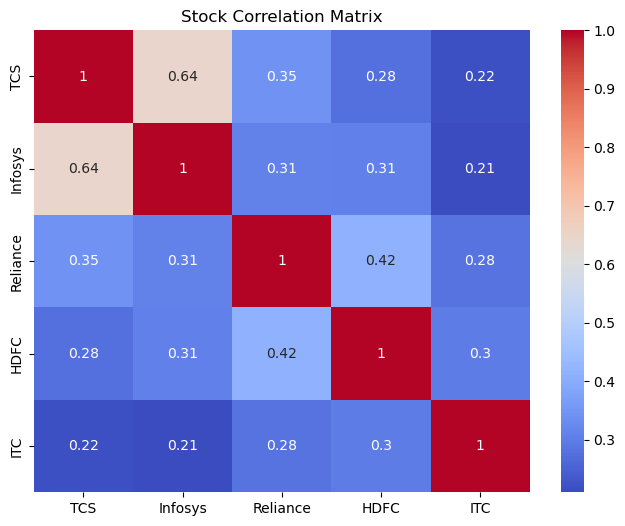

In [42]:
# correlation Heatmaop
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Stock Correlation Matrix"
)

plt.show() # having a inverse relation with diversification

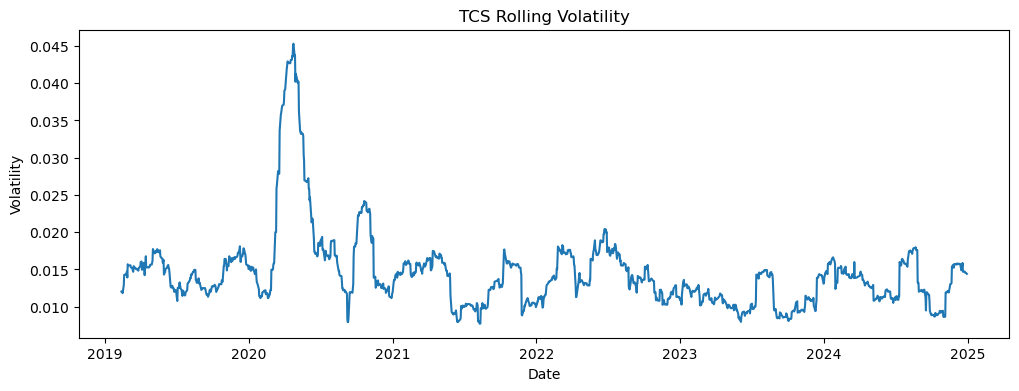

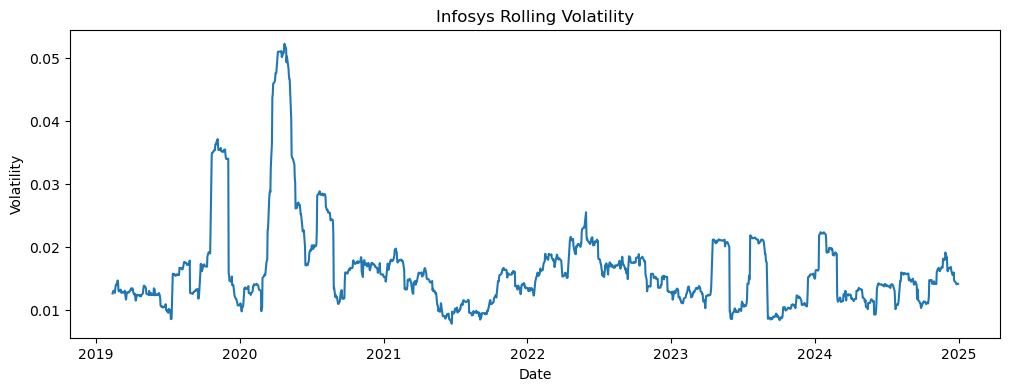

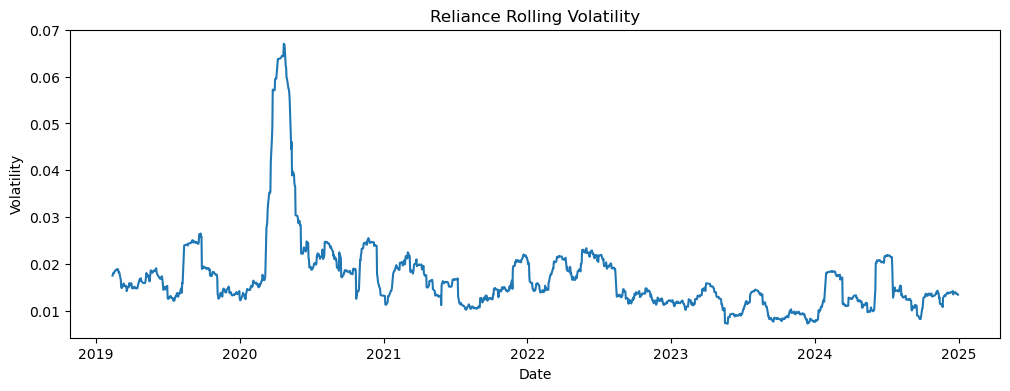

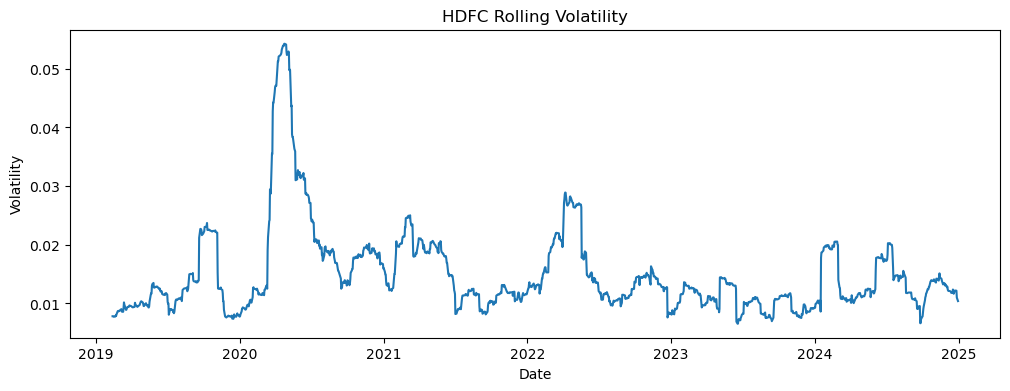

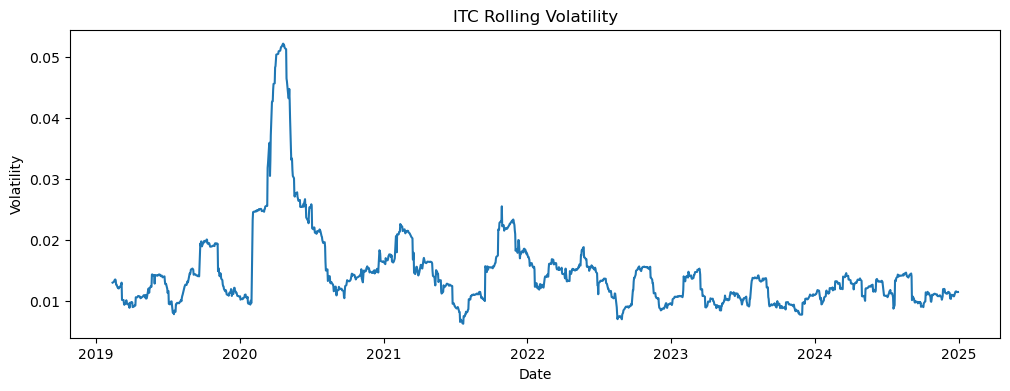

In [44]:
for stock,df in data.items():

    rolling_vol = (
        df["Return"]
        .rolling(30)
        .std()
    )

    plt.figure(figsize=(12,4))

    plt.plot(
        df["Date"],
        rolling_vol
    )

    plt.title(
        f"{stock} Rolling Volatility"
    )
    plt.xlabel("Date")
    plt.ylabel("Volatility")

    plt.show()

* Infosys exhibits the highest average return, while Reliance shows the highest volatility. Return distributions display significant kurtosis and heavy tails, indicating departures from normality. Correlation analysis reveals strong relationships among IT-sector stocks, motivating diversification strategies. The observed heavy tails suggest that Student-t models may better capture financial return behavior than Gaussian assumptions